<a href="https://colab.research.google.com/github/aleksandrabegovic/neural-network-stock-prediction/blob/main/neural_network_stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
from google.colab import drive
drive.mount('/content/drive')

# učitavanje potrebnih biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
amzn = pd.read_csv("/content/drive/MyDrive/amzn_final.csv")
aapl = pd.read_csv("/content/drive/MyDrive/aapl_final2.csv")
googl = pd.read_csv("/content/drive/MyDrive/googl_final.csv")
meta = pd.read_csv("/content/drive/MyDrive/meta_final.csv")
msft = pd.read_csv("/content/drive/MyDrive/msft_final.csv")
nvda = pd.read_csv("/content/drive/MyDrive/nvda_final.csv")
tsla = pd.read_csv("/content/drive/MyDrive/tsla_final.csv")

In [50]:
# Spajanje svih datasetova u jedan zajednički DataFrame
df = pd.concat([amzn, aapl, googl, meta, msft, nvda, tsla], ignore_index=True)

df["date"] = pd.to_datetime(df["date"])

# Sortiranje podataka prvo po kompaniji, a zatim po datumu
df = df.sort_values(["company", "date"]).reset_index(drop=True)

print(df.shape)
df["company"].value_counts()

(47109, 51)


,count
company,
AAPL,29725
AMZN,5389
GOOGL,3662
MSFT,3334
META,1912
TSLA,1674
NVDA,1413


In [51]:
df["sent_lag1"] = df.groupby("company")["sentiment_score"].shift(1)
# sent_lag1 predstavlja sentiment prethodne vesti/dana
# za istu kompaniju

df["sent_ma3"] = (
    df.groupby("company")["sentiment_score"]
      .rolling(3)
      .mean()
      .reset_index(level=0, drop=True)
)
# sent_ma3 predstavlja pokretni prosek sentiment score vrednosti
# kroz poslednja 3 posmatranja za svaku kompaniju


df["return_lag1"] = df.groupby("company")["return_close_close"].shift(1)
df["return_lag2"] = df.groupby("company")["return_close_close"].shift(2)
df["return_lag3"] = df.groupby("company")["return_close_close"].shift(3)
# Ove promenljive predstavljaju prinose iz prethodnih dana
# i omogućavaju modelu da koristi istorijske informacije

df["news_count"] = df.groupby(["company", "date"])["title"].transform("count")
# Broj vesti za svaku kompaniju po datumu

In [52]:
company_dummies = pd.get_dummies(df["company"], prefix="company")
# Pretvaranje kategorijske promenljive "company"
# u numerički oblik pomoću one-hot encoding metode
df = pd.concat([df, company_dummies], axis=1)

In [53]:
features = [
    "sentiment_score",
    "sentiment_num",
    "sent_lag1",
    "sent_ma3",
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "news_count",
] + list(company_dummies.columns)

target = "y_1d"
# y_1d predstavlja pravac kretanja akcije narednog dana

model_df = df[features + [target]].dropna()
# Kreiranje konačnog skupa podataka za model

X = model_df[features].values
y = model_df[target].values
# Formiranje matrice ulaznih podataka X
# i ciljne promenljive y za treniranje modela

In [54]:
# Podela podataka na trening i test skup
split_index = int(len(model_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [55]:
from sklearn.preprocessing import StandardScaler

# Standardizacija podataka

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Konverzija podataka u PyTorch tenzore

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [57]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# Kreiranje TensorDataset objekta

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [62]:
import torch.nn as nn

# Definisanje neuronske mreže za klasifikaciju
# Model ima više linearnih slojeva i ReLU aktivacione funkcije

class StockNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)
# Kreiranje instance modela
model = StockNN(input_dim=X_train.shape[1])

In [63]:
criterion = nn.BCELoss()
# Definisanje funkcije greške
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [60]:
epochs = 20
# Definisanje broja epoha za treniranje modela
losses = []
# Proces treniranja neuronske mreže
for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    # Računanje prosečne greške po epohi
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    # Ispis rezultata na svakih 10 epoha
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 10/20, Loss: 0.1377
Epoch 20/20, Loss: 0.1313


In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
# Model se postavlja u evaluation mode
# kako bi se isključile promene karakteristične za trening

with torch.no_grad():
    y_prob = model(X_test_tensor)
    y_pred = (y_prob >= 0.5).int().numpy().flatten()
# Pretvaranje verovatnoća u klase
# Ako je verovatnoća >= 0.5 predikcija je 1,
# u suprotnom predikcija je 0

y_true = y_test_tensor.numpy().flatten()

print("Accuracy:", accuracy_score(y_true, y_pred))
# Izračunavanje accuracy metrike
# koja pokazuje procenat tačno klasifikovanih primera
print(classification_report(y_true, y_pred))

Accuracy: 0.8296674104771012
              precision    recall  f1-score   support

         0.0       0.85      0.80      0.82      4682
         1.0       0.82      0.85      0.83      4729

    accuracy                           0.83      9411
   macro avg       0.83      0.83      0.83      9411
weighted avg       0.83      0.83      0.83      9411



In [64]:
epochs = 50
# Definisanje broja epoha za treniranje modela
losses = []
# Proces treniranja neuronske mreže
for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    # Računanje prosečne greške po epohi
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    # Ispis rezultata na svakih 10 epoha
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 10/50, Loss: 0.1337
Epoch 20/50, Loss: 0.1296
Epoch 30/50, Loss: 0.1275
Epoch 40/50, Loss: 0.1262
Epoch 50/50, Loss: 0.1249


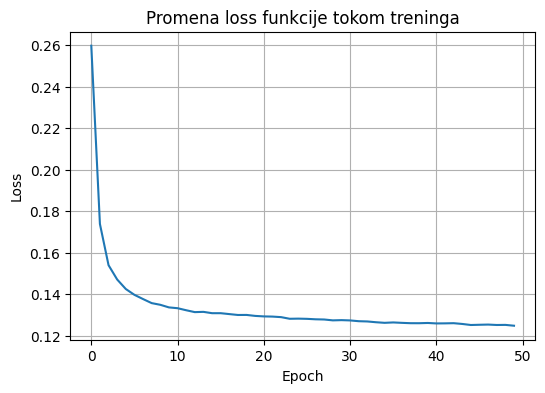

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Promena loss funkcije tokom treninga")
plt.grid()
plt.show()

Na osnovu prikazanog grafikona može se zaključiti da je neuronska mreža uspešno učila tokom procesa treniranja. Na početku treniranja vrednost loss funkcije bila je relativno visoka, što ukazuje da model u početnim epohama nije dobro predviđao ciljnu promenljivu. Međutim, već nakon nekoliko epoha dolazi do naglog opadanja loss vrednosti, što pokazuje da model brzo pronalazi obrasce u podacima.

In [66]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
# Model se postavlja u evaluation mode
# kako bi se isključile promene karakteristične za trening

with torch.no_grad():
    y_prob = model(X_test_tensor)
    y_pred = (y_prob >= 0.5).int().numpy().flatten()
# Pretvaranje verovatnoća u klase
# Ako je verovatnoća >= 0.5 predikcija je 1,
# u suprotnom predikcija je 0

y_true = y_test_tensor.numpy().flatten()

print("Accuracy:", accuracy_score(y_true, y_pred))
# Izračunavanje accuracy metrike
# koja pokazuje procenat tačno klasifikovanih primera
print(classification_report(y_true, y_pred))

Accuracy: 0.8409308256295824
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84      4682
         1.0       0.84      0.85      0.84      4729

    accuracy                           0.84      9411
   macro avg       0.84      0.84      0.84      9411
weighted avg       0.84      0.84      0.84      9411



Na osnovu dobijenih rezultata može se zaključiti da neuronska mreža ostvaruje veoma dobre performanse u zadatku predikcije kretanja akcija. Ukupna tačnost modela iznosi približno 84,1%, što pokazuje da model uspešno prepoznaje obrasce između sentimenta finansijskih vesti, istorijskih prinosa i budućeg pravca kretanja akcije.

Vrednosti precision, recall i F1-score metrika za obe klase su visoke i međusobno uravnotežene, što ukazuje da model nema izraženu pristrasnost prema jednoj klasi. Za klasu 0 (DOWN) model ostvaruje precision od 0,85, recall od 0,83 i F1-score od 0,84, dok za klasu 1 (UP) precision iznosi 0,84, recall 0,85, a F1-score 0,84. Ovi rezultati pokazuju da model podjednako uspešno prepoznaje i rast i pad akcija, uz stabilne performanse na test skupu.

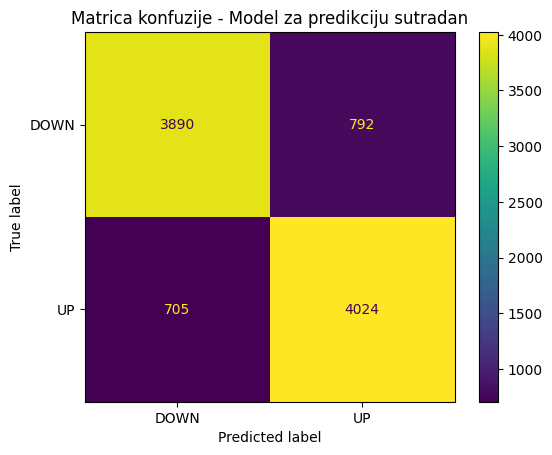

In [67]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DOWN", "UP"]
)

disp.plot()
plt.title("Matrica konfuzije - Model za predikciju sutradan")
plt.show()

Model je tačno predvideo 3890 slučajeva pada akcije (DOWN), kao i 4024 slučaja rasta akcije (UP). Ove vrednosti se nalaze na glavnoj dijagonali matrice i predstavljaju ispravne klasifikacije modela.

Sa druge strane, model je napravio određeni broj grešaka. U 792 slučaja model je predvideo rast akcije (UP), iako je stvarna vrednost bila pad (DOWN). Takođe, u 705 slučajeva model je predvideo pad akcije (DOWN), dok je stvarna vrednost bila rast (UP).

# **Model bez istorijskih prinosa akcija**

In [6]:
safe_features = [
    "sentiment_score",
    "sentiment_num",
    "sent_lag1",
    "sent_ma3",
    "news_count",
] + list(company_dummies.columns)

target = "y_1d"

model_df_safe = df[safe_features + [target]].dropna()

X = model_df_safe[safe_features].values
y = model_df_safe[target].values

In [7]:
split_index = int(len(model_df_safe) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [10]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [11]:
import torch.nn as nn

class StockNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = StockNN(input_dim=X_train.shape[1])

In [12]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [13]:
epochs = 50

losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/50, Loss: 0.6916
Epoch 2/50, Loss: 0.6904
Epoch 3/50, Loss: 0.6901
Epoch 4/50, Loss: 0.6898
Epoch 5/50, Loss: 0.6894
Epoch 6/50, Loss: 0.6892
Epoch 7/50, Loss: 0.6889
Epoch 8/50, Loss: 0.6886
Epoch 9/50, Loss: 0.6883
Epoch 10/50, Loss: 0.6878
Epoch 11/50, Loss: 0.6872
Epoch 12/50, Loss: 0.6870
Epoch 13/50, Loss: 0.6866
Epoch 14/50, Loss: 0.6858
Epoch 15/50, Loss: 0.6855
Epoch 16/50, Loss: 0.6851
Epoch 17/50, Loss: 0.6845
Epoch 18/50, Loss: 0.6843
Epoch 19/50, Loss: 0.6841
Epoch 20/50, Loss: 0.6832
Epoch 21/50, Loss: 0.6832
Epoch 22/50, Loss: 0.6830
Epoch 23/50, Loss: 0.6826
Epoch 24/50, Loss: 0.6824
Epoch 25/50, Loss: 0.6822
Epoch 26/50, Loss: 0.6818
Epoch 27/50, Loss: 0.6817
Epoch 28/50, Loss: 0.6818
Epoch 29/50, Loss: 0.6815
Epoch 30/50, Loss: 0.6814
Epoch 31/50, Loss: 0.6809
Epoch 32/50, Loss: 0.6807
Epoch 33/50, Loss: 0.6805
Epoch 34/50, Loss: 0.6803
Epoch 35/50, Loss: 0.6802
Epoch 36/50, Loss: 0.6798
Epoch 37/50, Loss: 0.6798
Epoch 38/50, Loss: 0.6798
Epoch 39/50, Loss: 0.

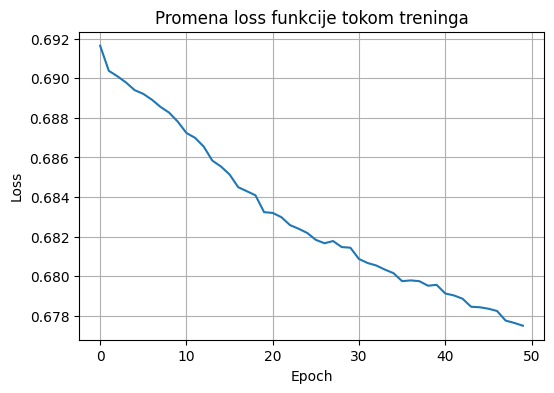

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Promena loss funkcije tokom treninga")

plt.grid()

plt.show()

Tokom 50 epoha vrednost loss funkcije se postepeno smanjuje, što pokazuje da model uspešno uči iz podataka i postepeno poboljšava svoje performanse. Nisu uočene značajne oscilacije, što pokazuje na stabilan proces treniranja.

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model.eval()

with torch.no_grad():

    y_prob = model(X_test_tensor)

    y_pred = (
        y_prob >= 0.5
    ).int().numpy().flatten()

y_true = y_test_tensor.numpy().flatten()

print("Accuracy:", accuracy_score(y_true, y_pred))

print(classification_report(y_true, y_pred))

Accuracy: 0.5032936676583085
              precision    recall  f1-score   support

         0.0       0.54      0.01      0.02      4683
         1.0       0.50      0.99      0.67      4729

    accuracy                           0.50      9412
   macro avg       0.52      0.50      0.34      9412
weighted avg       0.52      0.50      0.35      9412



Rezultati evaluacije pokazuju da model bez istorijskih tržišnih podataka ostvaruje tačnost od približno 50,32%, što je veoma blizu nivou slučajnog pogađanja kod binarne klasifikacije. Iako model veoma uspešno prepoznaje primere klase UP (recall = 0,99), istovremeno ne uspeva da prepozna primere klase DOWN (recall = 0,01). Ovakvi rezultati ukazuju da se model pretežno opredeljuje za predviđanje klase UP, zbog čega ostvaruje slabe ukupne performanse. Dobijeni rezultati potvrđuju da sentiment karakteristike, broj vesti i informacija o kompaniji nisu dovoljni za pouzdanu predikciju kretanja akcija bez uključivanja istorijskih tržišnih podataka.

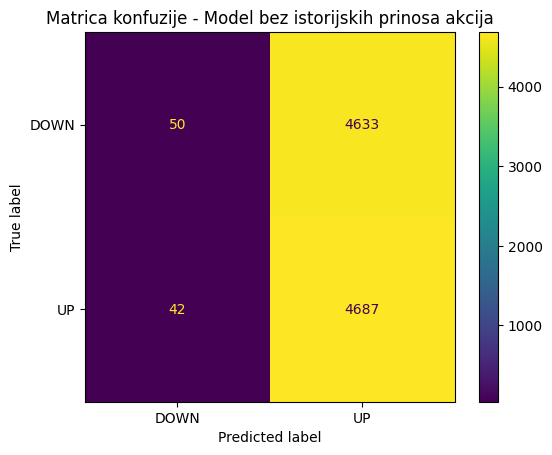

In [16]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DOWN", "UP"]
)

disp.plot()

plt.title("Matrica konfuzije - Model bez istorijskih prinosa akcija")

plt.show()

Matrica konfuzije pokazuje da model bez istorijskih tržišnih podataka gotovo uvek predviđa klasu UP, bez obzira na stvarnu vrednost. Od ukupno 4683 slučaja pada akcije (DOWN), model je ispravno prepoznao samo 50, dok je 4633 pogrešno klasifikovao kao rast akcije (UP). Sa druge strane, od 4729 slučajeva rasta akcije (UP), model je ispravno klasifikovao 4687, dok je samo 42 slučaja pogrešno označio kao pad akcije (DOWN). Ovakva raspodela potvrđuje da model nije uspeo da nauči dovoljno informacija za pouzdano razlikovanje rasta i pada akcija kada koristi samo sentiment karakteristike, broj vesti i informaciju o kompaniji.

# **Predikcija kretanja akcija dva dana unapred (2D)**

In [17]:
features = [
    "sentiment_score",
    "sentiment_num",
    "sent_lag1",
    "sent_ma3",
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "news_count",
] + list(company_dummies.columns)

# target za dva dana

target = "y_2d"

model_df = df[features + [target]].dropna()

X = model_df[features].values
y = model_df[target].values

In [18]:
split_index = int(len(model_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1,1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1,1)

In [21]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [22]:
import torch.nn as nn

class StockNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.net(x)

model = StockNN(
    input_dim=X_train.shape[1]
)

In [23]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [24]:
epochs = 50

losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}"
    )

Epoch 1/50, Loss: 0.5501
Epoch 2/50, Loss: 0.5345
Epoch 3/50, Loss: 0.5319
Epoch 4/50, Loss: 0.5302
Epoch 5/50, Loss: 0.5284
Epoch 6/50, Loss: 0.5265
Epoch 7/50, Loss: 0.5247
Epoch 8/50, Loss: 0.5242
Epoch 9/50, Loss: 0.5226
Epoch 10/50, Loss: 0.5215
Epoch 11/50, Loss: 0.5203
Epoch 12/50, Loss: 0.5195
Epoch 13/50, Loss: 0.5186
Epoch 14/50, Loss: 0.5177
Epoch 15/50, Loss: 0.5171
Epoch 16/50, Loss: 0.5161
Epoch 17/50, Loss: 0.5161
Epoch 18/50, Loss: 0.5146
Epoch 19/50, Loss: 0.5142
Epoch 20/50, Loss: 0.5142
Epoch 21/50, Loss: 0.5130
Epoch 22/50, Loss: 0.5131
Epoch 23/50, Loss: 0.5124
Epoch 24/50, Loss: 0.5118
Epoch 25/50, Loss: 0.5113
Epoch 26/50, Loss: 0.5102
Epoch 27/50, Loss: 0.5098
Epoch 28/50, Loss: 0.5090
Epoch 29/50, Loss: 0.5091
Epoch 30/50, Loss: 0.5082
Epoch 31/50, Loss: 0.5080
Epoch 32/50, Loss: 0.5075
Epoch 33/50, Loss: 0.5074
Epoch 34/50, Loss: 0.5065
Epoch 35/50, Loss: 0.5060
Epoch 36/50, Loss: 0.5055
Epoch 37/50, Loss: 0.5050
Epoch 38/50, Loss: 0.5045
Epoch 39/50, Loss: 0.

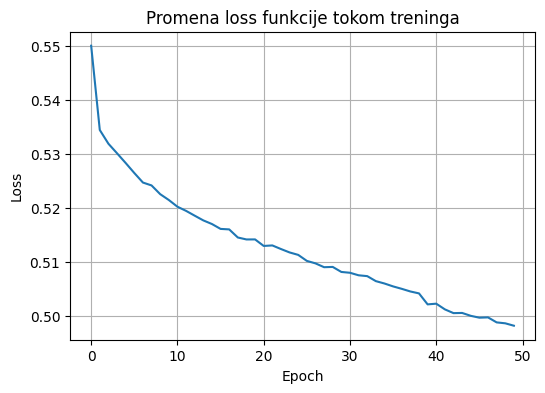

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Promena loss funkcije tokom treninga"
)

plt.grid()

plt.show()

In [26]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model.eval()

with torch.no_grad():

    y_prob = model(X_test_tensor)

    y_pred = (
        y_prob >= 0.5
    ).int().numpy().flatten()

y_true = y_test_tensor.numpy().flatten()

print(
    "Accuracy:",
    accuracy_score(y_true, y_pred)
)

print(
    classification_report(
        y_true,
        y_pred
    )
)

Accuracy: 0.657315906917437
              precision    recall  f1-score   support

         0.0       0.64      0.64      0.64      4493
         1.0       0.67      0.67      0.67      4918

    accuracy                           0.66      9411
   macro avg       0.66      0.66      0.66      9411
weighted avg       0.66      0.66      0.66      9411



Rezultati evaluacije za predikciju kretanja akcija dva dana unapred pokazuju da model ostvaruje tačnost od približno 65,73%. Vrednosti metrika precision, recall i F1-score kreću se između 0,64 i 0,67 za obe klase, što ukazuje na relativno uravnotežene performanse modela. Za klasu DOWN ostvareni su precision, recall i F1-score od 0,64, dok za klasu UP sve tri metrike iznose 0,67. U poređenju sa modelom za predikciju jedan dan unapred, uočava se pad performansi, što je očekivano zbog većeg vremenskog horizonta predikcije. Ipak, model i dalje uspeva da prepozna značajan deo obrazaca prisutnih u podacima i ostvaruje rezultate znatno bolje od slučajnog pogađanja.

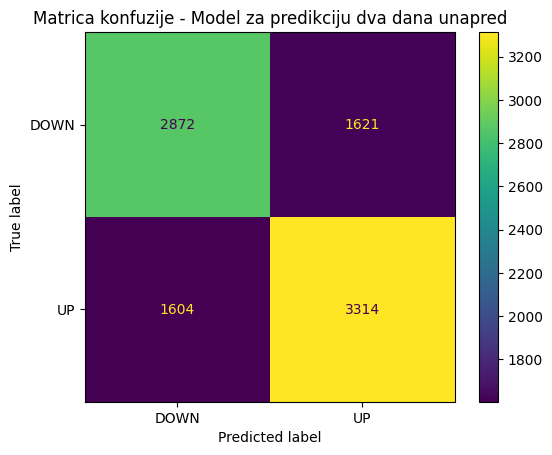

In [27]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DOWN", "UP"]
)

disp.plot()

plt.title(
    "Matrica konfuzije - Model za predikciju dva dana unapred"
)

plt.show()

Matrica konfuzije za model koji predviđa kretanje akcija dva dana unapred pokazuje relativno uravnotežene performanse za obe klase. Model je ispravno klasifikovao 2872 slučaja pada akcije (DOWN) i 3314 slučajeva rasta akcije (UP). Istovremeno, 1621 slučaj pada akcije pogrešno je klasifikovan kao rast, dok je 1604 slučaja rasta pogrešno označeno kao pad. Sličan broj grešaka u obe klase ukazuje da model nema izraženu pristrasnost prema jednoj klasi i da podjednako dobro prepoznaje i rast i pad akcija. Dobijeni rezultati potvrđuju da model zadržava solidne performanse i pri predikciji dva dana unapred, ostvarujući tačnost od približno 65,73%.

# **Predikcija kretanja akcija tri dana unapred (3D)**

In [28]:
features = [
    "sentiment_score",
    "sentiment_num",
    "sent_lag1",
    "sent_ma3",
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "news_count",
] + list(company_dummies.columns)

# target za tri dana

target = "y_3d"

model_df = df[features + [target]].dropna()

X = model_df[features].values
y = model_df[target].values


In [29]:
split_index = int(len(model_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1,1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1,1)

In [32]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [33]:
import torch.nn as nn

class StockNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.net(x)

model = StockNN(
    input_dim=X_train.shape[1]
)


In [34]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
epochs = 50

losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}"
    )

Epoch 1/50, Loss: 0.6185
Epoch 2/50, Loss: 0.6098
Epoch 3/50, Loss: 0.6075
Epoch 4/50, Loss: 0.6061
Epoch 5/50, Loss: 0.6044
Epoch 6/50, Loss: 0.6027
Epoch 7/50, Loss: 0.6014
Epoch 8/50, Loss: 0.6001
Epoch 9/50, Loss: 0.5992
Epoch 10/50, Loss: 0.5982
Epoch 11/50, Loss: 0.5976
Epoch 12/50, Loss: 0.5964
Epoch 13/50, Loss: 0.5960
Epoch 14/50, Loss: 0.5950
Epoch 15/50, Loss: 0.5945
Epoch 16/50, Loss: 0.5934
Epoch 17/50, Loss: 0.5929
Epoch 18/50, Loss: 0.5920
Epoch 19/50, Loss: 0.5913
Epoch 20/50, Loss: 0.5907
Epoch 21/50, Loss: 0.5900
Epoch 22/50, Loss: 0.5893
Epoch 23/50, Loss: 0.5884
Epoch 24/50, Loss: 0.5879
Epoch 25/50, Loss: 0.5877
Epoch 26/50, Loss: 0.5864
Epoch 27/50, Loss: 0.5858
Epoch 28/50, Loss: 0.5849
Epoch 29/50, Loss: 0.5844
Epoch 30/50, Loss: 0.5842
Epoch 31/50, Loss: 0.5829
Epoch 32/50, Loss: 0.5825
Epoch 33/50, Loss: 0.5817
Epoch 34/50, Loss: 0.5812
Epoch 35/50, Loss: 0.5808
Epoch 36/50, Loss: 0.5800
Epoch 37/50, Loss: 0.5794
Epoch 38/50, Loss: 0.5783
Epoch 39/50, Loss: 0.

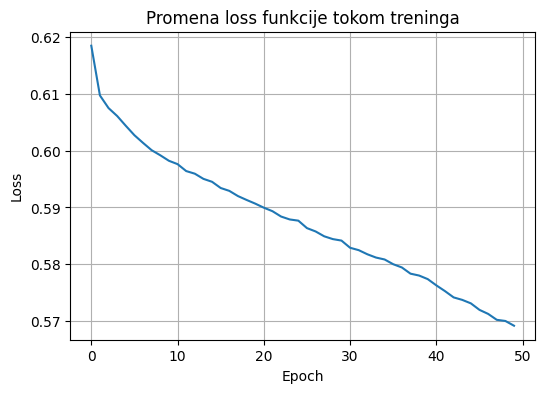

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Promena loss funkcije tokom treninga"
)

plt.grid()

plt.show()

In [37]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model.eval()

with torch.no_grad():

    y_prob = model(X_test_tensor)

    y_pred = (
        y_prob >= 0.5
    ).int().numpy().flatten()

y_true = y_test_tensor.numpy().flatten()

print(
    "Accuracy:",
    accuracy_score(y_true, y_pred)
)

print(
    classification_report(
        y_true,
        y_pred
    )
)

Accuracy: 0.5991924343852938
              precision    recall  f1-score   support

         0.0       0.56      0.58      0.57      4344
         1.0       0.63      0.61      0.62      5067

    accuracy                           0.60      9411
   macro avg       0.60      0.60      0.60      9411
weighted avg       0.60      0.60      0.60      9411



Rezultati evaluacije za predikciju kretanja akcija tri dana unapred pokazuju da model ostvaruje tačnost od približno 59,92%. Vrednosti metrika precision, recall i F1-score kreću se između 0,56 i 0,63, što ukazuje na umerene performanse modela. Za klasu DOWN ostvareni su precision od 0,56, recall od 0,58 i F1-score od 0,57, dok za klasu UP precision iznosi 0,63, recall 0,61, a F1-score 0,62. U poređenju sa modelom za predikciju jedan dan unapred, uočava se pad performansi, što je očekivano zbog veće neizvesnosti pri predviđanju kretanja akcija na duži vremenski period. Ipak, model i dalje ostvaruje rezultate bolje od slučajnog pogađanja i uspeva da prepozna deo obrazaca prisutnih u podacima.

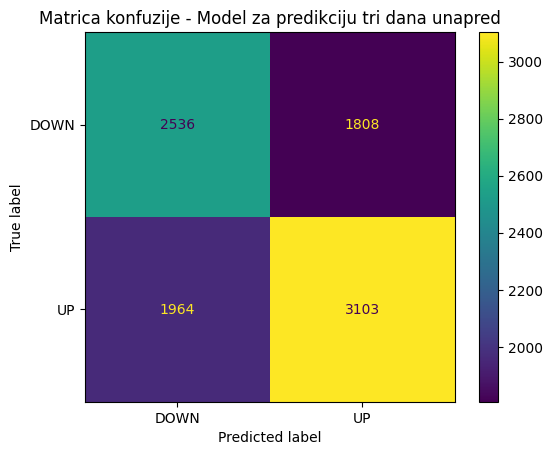

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DOWN", "UP"]
)

disp.plot()

plt.title(
    "Matrica konfuzije - Model za predikciju tri dana unapred"
)

plt.show()

Matrica konfuzije za model koji predviđa kretanje akcija tri dana unapred pokazuje umerene i relativno uravnotežene performanse za obe klase. Model je ispravno klasifikovao 2536 slučajeva pada akcije (DOWN) i 3103 slučaja rasta akcije (UP). Istovremeno, 1808 slučajeva pada pogrešno je klasifikovano kao rast, dok je 1964 slučaja rasta pogrešno označeno kao pad. Sličan broj grešaka u obe klase ukazuje da model nema izraženu pristrasnost prema jednoj klasi. U poređenju sa modelima za predikciju jedan i dva dana unapred, uočava se veći broj pogrešnih klasifikacija, što je očekivano zbog povećane neizvesnosti pri predviđanju kretanja akcija na duži vremenski horizont.